# Import packages

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.functions import col, count, when
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

In [0]:
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# Spark session

In [0]:
print(f"Spark version: {spark.version}")
print(f"MLflow version: {mlflow.__version__}")

Spark version: 4.1.0
MLflow version: 2.22.0


# Setup catalog and schema

In [0]:
CATALOG = "workspace"
SCHEMA = "taxi_lab" 

In [0]:
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}")
spark.sql(f"USE CATALOG {CATALOG}")
spark.sql(f"USE SCHEMA {SCHEMA}")

DataFrame[]

# Diccionario de datos

| Variable | Origen | Tipo | Descripción |
|---|---|---|---|
| `tpep_pickup_datetime` | Bronze (origen) | timestamp | Fecha y hora de inicio del viaje |
| `tpep_dropoff_datetime` | Bronze (origen) | timestamp | Fecha y hora de fin del viaje |
| `trip_distance` | Bronze (origen) | double | Distancia recorrida en millas |
| `fare_amount` | Bronze (origen) | double | Tarifa cobrada al pasajero en USD (variable objetivo del modelo) |
| `pickup_zip` | Bronze (origen) | int | Código postal del lugar de inicio del viaje |
| `dropoff_zip` | Bronze (origen) | int | Código postal del lugar de fin del viaje |
| `pickup_hour` | Silver (derivada) | int | Hora del día en que inicia el viaje (0 a 23) |
| `pickup_dayofweek` | Silver (derivada) | int | Día de la semana del inicio del viaje (1=domingo, 7=sábado) |
| `pickup_day` | Silver (derivada) | int | Día del mes del inicio del viaje |
| `pickup_month` | Silver (derivada) | int | Mes del inicio del viaje |
| `pickup_year` | Silver (derivada) | int | Año del inicio del viaje |
| `trip_duration_min` | Silver (derivada) | double | Duración del viaje en minutos |
| `is_weekend` | Silver (derivada) | int | Indicador binario de fin de semana (1=sábado o domingo, 0=resto) |
| `time_of_day` | Silver (derivada) | string | Franja horaria: morning (6-11), afternoon (12-17), evening (18-21), night (22-5) |
| `avg_speed_mph` | Silver (derivada) | double | Velocidad promedio del viaje en millas por hora |
| `total_trips` | Gold (agregada) | bigint | Cantidad total de viajes en el grupo |
| `avg_fare` | Gold (agregada) | double | Tarifa promedio del grupo en USD |
| `avg_distance_mi` | Gold (agregada) | double | Distancia promedio del grupo en millas |
| `avg_duration_min` | Gold (agregada) | double | Duración promedio del grupo en minutos |
| `total_revenue` | Gold (agregada) | double | Ingresos totales acumulados del grupo en USD |
| `avg_speed` | Gold (agregada) | double | Velocidad promedio del grupo en millas por hora |

# Raw data -> Bronze layer

In [0]:
df_raw = spark.read.table("samples.nyctaxi.trips")

In [0]:
df_raw.printSchema()

root
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- pickup_zip: integer (nullable = true)
 |-- dropoff_zip: integer (nullable = true)



In [0]:
display(df_raw.limit(10))

tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,pickup_zip,dropoff_zip
2016-02-13T21:47:53.000Z,2016-02-13T21:57:15.000Z,1.4,8.0,10103,10110
2016-02-13T18:29:09.000Z,2016-02-13T18:37:23.000Z,1.31,7.5,10023,10023
2016-02-06T19:40:58.000Z,2016-02-06T19:52:32.000Z,1.8,9.5,10001,10018
2016-02-12T19:06:43.000Z,2016-02-12T19:20:54.000Z,2.3,11.5,10044,10111
2016-02-23T10:27:56.000Z,2016-02-23T10:58:33.000Z,2.6,18.5,10199,10022
2016-02-13T00:41:43.000Z,2016-02-13T00:46:52.000Z,1.4,6.5,10023,10069
2016-02-18T23:49:53.000Z,2016-02-19T00:12:53.000Z,10.4,31.0,11371,10003
2016-02-18T20:21:45.000Z,2016-02-18T20:38:23.000Z,10.15,28.5,11371,11201
2016-02-03T10:47:50.000Z,2016-02-03T11:07:06.000Z,3.27,15.0,10014,10023
2016-02-19T01:26:39.000Z,2016-02-19T01:40:01.000Z,4.42,15.0,10003,11222


In [0]:
total_rows = df_raw.count()
print(f"Total de viajes: {total_rows:,}")

Total de viajes: 21,932


In [0]:
%sql
DROP TABLE IF EXISTS workspace.taxi_lab.bronze_trips;
DROP TABLE IF EXISTS workspace.taxi_lab.silver_trips;
DROP TABLE IF EXISTS workspace.taxi_lab.gold_zone_metrics;

In [0]:
(df_raw
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(f"{CATALOG}.{SCHEMA}.bronze_trips")
)

In [0]:
%sql
SELECT * FROM workspace.taxi_lab.bronze_trips LIMIT 5

tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,pickup_zip,dropoff_zip
2016-02-13T21:47:53.000Z,2016-02-13T21:57:15.000Z,1.4,8.0,10103,10110
2016-02-13T18:29:09.000Z,2016-02-13T18:37:23.000Z,1.31,7.5,10023,10023
2016-02-06T19:40:58.000Z,2016-02-06T19:52:32.000Z,1.8,9.5,10001,10018
2016-02-12T19:06:43.000Z,2016-02-12T19:20:54.000Z,2.3,11.5,10044,10111
2016-02-23T10:27:56.000Z,2016-02-23T10:58:33.000Z,2.6,18.5,10199,10022


# Silver layer

In [0]:
display(df_raw.select("trip_distance", "fare_amount").describe())

summary,trip_distance,fare_amount
count,21932,21932
mean,2.852829199343427,12.34872697428415
stddev,3.4399536210623527,10.327887859233327
min,0.0,-8.0
max,30.6,275.0


In [0]:
quality_check = df_raw.select([
    count(when(col("fare_amount") <= 0, True)).alias("fare_negativa_o_cero"),
    count(when(col("trip_distance") <= 0, True)).alias("distancia_cero_o_neg"),
    count(when(col("trip_distance") > 100, True)).alias("distancia_mayor_100mi"),
    count(when(col("fare_amount") > 500, True)).alias("fare_mayor_500"),
    count(when(col("tpep_pickup_datetime").isNull(), True)).alias("pickup_null"),
    count(when(col("tpep_dropoff_datetime") < col("tpep_pickup_datetime"), True)).alias("dropoff_antes_pickup"),
])

display(quality_check)

fare_negativa_o_cero,distancia_cero_o_neg,distancia_mayor_100mi,fare_mayor_500,pickup_null,dropoff_antes_pickup
10,76,0,0,0,0


In [0]:
df_clean = (df_raw
    .filter(F.col("fare_amount") > 0)
    .filter(F.col("fare_amount") <= 500)
    .filter(F.col("trip_distance") > 0)
    .filter(F.col("trip_distance") <= 100)
    .filter(F.col("tpep_dropoff_datetime") > F.col("tpep_pickup_datetime"))
    .filter(F.col("pickup_zip").isNotNull())
    .filter(F.col("dropoff_zip").isNotNull())
)

In [0]:
filas_clean = df_clean.count()
filas_descartadas = total_rows - filas_clean
pct_descartado = filas_descartadas / total_rows * 100

print(f"Filas originales: {total_rows:,}")
print(f"Filas limpias:    {filas_clean:,}")
print(f"Descartadas:      {filas_descartadas:,} ({pct_descartado:.2f}%)")

Filas originales: 21,932
Filas limpias:    21,847
Descartadas:      85 (0.39%)


In [0]:
df_silver = (df_clean
    .withColumn("pickup_hour",      F.hour("tpep_pickup_datetime"))
    .withColumn("pickup_dayofweek", F.dayofweek("tpep_pickup_datetime"))
    .withColumn("pickup_day",       F.dayofmonth("tpep_pickup_datetime"))
    .withColumn("pickup_month",     F.month("tpep_pickup_datetime"))
    .withColumn("pickup_year",      F.year("tpep_pickup_datetime"))
    .withColumn("trip_duration_min",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
    )
    .withColumn("is_weekend", F.col("pickup_dayofweek").isin([1, 7]).cast("int"))
    .withColumn("time_of_day",
        F.when((F.col("pickup_hour") >= 6) & (F.col("pickup_hour") < 12), "morning")
         .when((F.col("pickup_hour") >= 12) & (F.col("pickup_hour") < 18), "afternoon")
         .when((F.col("pickup_hour") >= 18) & (F.col("pickup_hour") < 22), "evening")
         .otherwise("night")
    )
    .withColumn("avg_speed_mph",
        F.when(F.col("trip_duration_min") > 0,
               F.col("trip_distance") / (F.col("trip_duration_min") / 60))
         .otherwise(None)
    )
)

In [0]:
df_silver = (df_silver
    .filter(F.col("trip_duration_min").between(1, 180))
    .filter(F.col("avg_speed_mph").between(1, 80))
)

In [0]:
print(f"Silver final: {df_silver.count():,} filas")
display(df_silver.limit(5))

Silver final: 21,731 filas


tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,pickup_zip,dropoff_zip,pickup_hour,pickup_dayofweek,pickup_day,pickup_month,pickup_year,trip_duration_min,is_weekend,time_of_day,avg_speed_mph
2016-02-13T21:47:53.000Z,2016-02-13T21:57:15.000Z,1.4,8.0,10103,10110,21,7,13,2,2016,9.366666666666667,1,evening,8.967971530249109
2016-02-13T18:29:09.000Z,2016-02-13T18:37:23.000Z,1.31,7.5,10023,10023,18,7,13,2,2016,8.233333333333333,1,evening,9.546558704453442
2016-02-06T19:40:58.000Z,2016-02-06T19:52:32.000Z,1.8,9.5,10001,10018,19,7,6,2,2016,11.566666666666666,1,evening,9.337175792507205
2016-02-12T19:06:43.000Z,2016-02-12T19:20:54.000Z,2.3,11.5,10044,10111,19,6,12,2,2016,14.183333333333334,0,evening,9.729729729729728
2016-02-23T10:27:56.000Z,2016-02-23T10:58:33.000Z,2.6,18.5,10199,10022,10,3,23,2,2016,30.616666666666667,0,morning,5.095264017419706


In [0]:
(df_silver
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(f"{CATALOG}.{SCHEMA}.silver_trips")
)

# Gold layer

In [0]:
df_gold = (df_silver
    .groupBy("pickup_zip", "time_of_day")
    .agg(
        F.count("*").alias("total_trips"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
        F.round(F.avg("trip_distance"), 2).alias("avg_distance_mi"),
        F.round(F.avg("trip_duration_min"), 1).alias("avg_duration_min"),
        F.round(F.sum("fare_amount"), 2).alias("total_revenue"),
        F.round(F.avg("avg_speed_mph"), 1).alias("avg_speed")
    )
    .orderBy(F.col("total_revenue").desc())
)

In [0]:
(df_gold
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(f"{CATALOG}.{SCHEMA}.gold_zone_metrics")
)

In [0]:
display(df_gold.limit(20))

pickup_zip,time_of_day,total_trips,avg_fare,avg_distance_mi,avg_duration_min,total_revenue,avg_speed
11422,afternoon,131,47.29,16.35,45.4,6195.0,23.0
11422,evening,109,44.92,15.84,34.5,4896.5,28.3
11371,afternoon,154,31.26,9.56,30.3,4814.0,20.2
10003,night,372,12.53,3.14,12.8,4661.0,13.7
10002,night,323,12.69,3.14,12.7,4099.5,13.9
10001,afternoon,375,10.61,2.01,13.0,3979.0,8.9
11422,morning,85,45.82,15.95,40.1,3894.5,26.7
10021,afternoon,390,9.91,1.81,11.8,3863.5,9.5
11422,night,89,43.11,15.55,26.6,3836.5,35.7
11371,evening,125,30.63,9.87,25.5,3829.0,24.2


# EDA

In [0]:
%sql
SELECT
    pickup_hour,
    COUNT(*) AS total_trips,
    ROUND(AVG(fare_amount), 2) AS avg_fare
FROM workspace.taxi_lab.silver_trips
GROUP BY pickup_hour
ORDER BY pickup_hour

pickup_hour,total_trips,avg_fare
0,739,13.22
1,567,12.84
2,439,13.07
3,299,13.4
4,246,14.81
5,212,14.89
6,472,12.18
7,793,11.47
8,1032,12.03
9,1030,11.94


In [0]:
df_hours_ = spark.sql('''
    SELECT
        pickup_hour,
        COUNT(*) AS total_trips,
        ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM workspace.taxi_lab.silver_trips
    GROUP BY pickup_hour
    ORDER BY pickup_hour
''')

In [0]:
df_hours_.show()

+-----------+-----------+--------+
|pickup_hour|total_trips|avg_fare|
+-----------+-----------+--------+
|          0|        739|   13.22|
|          1|        567|   12.84|
|          2|        439|   13.07|
|          3|        299|    13.4|
|          4|        246|   14.81|
|          5|        212|   14.89|
|          6|        472|   12.18|
|          7|        793|   11.47|
|          8|       1032|   12.03|
|          9|       1030|   11.94|
|         10|        959|   12.06|
|         11|       1004|   11.84|
|         12|       1043|   11.44|
|         13|       1086|   12.11|
|         14|       1096|   12.65|
|         15|       1164|   13.17|
|         16|        968|   12.04|
|         17|       1180|   12.58|
|         18|       1442|   11.61|
|         19|       1384|   11.39|
+-----------+-----------+--------+
only showing top 20 rows


In [0]:
df_hours_to_plot = df_hours_.toPandas()

<Axes: xlabel='pickup_hour', ylabel='avg_fare'>

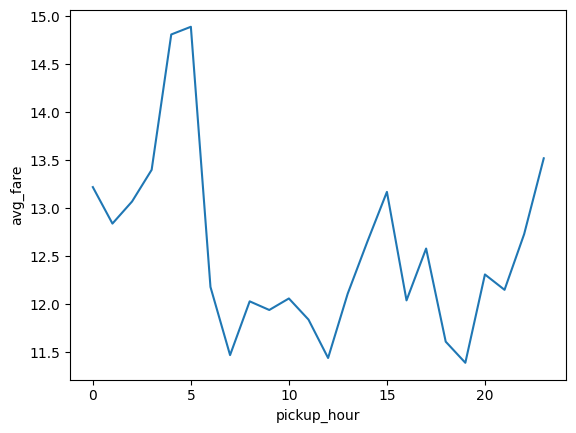

In [0]:
sns.lineplot(x="pickup_hour", y="avg_fare", data=df_hours_to_plot)

<Axes: xlabel='pickup_hour', ylabel='total_trips'>

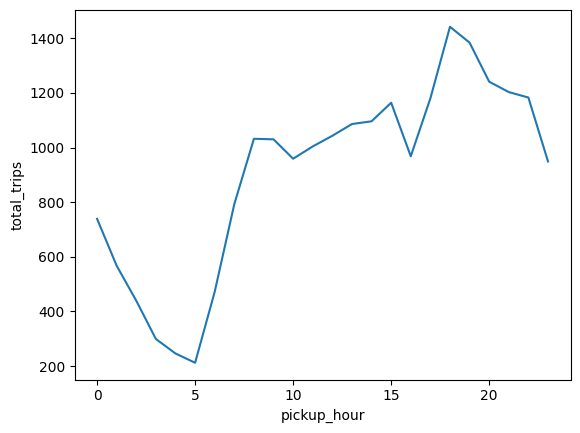

In [0]:
sns.lineplot(x="pickup_hour", y="total_trips", data=df_hours_to_plot)

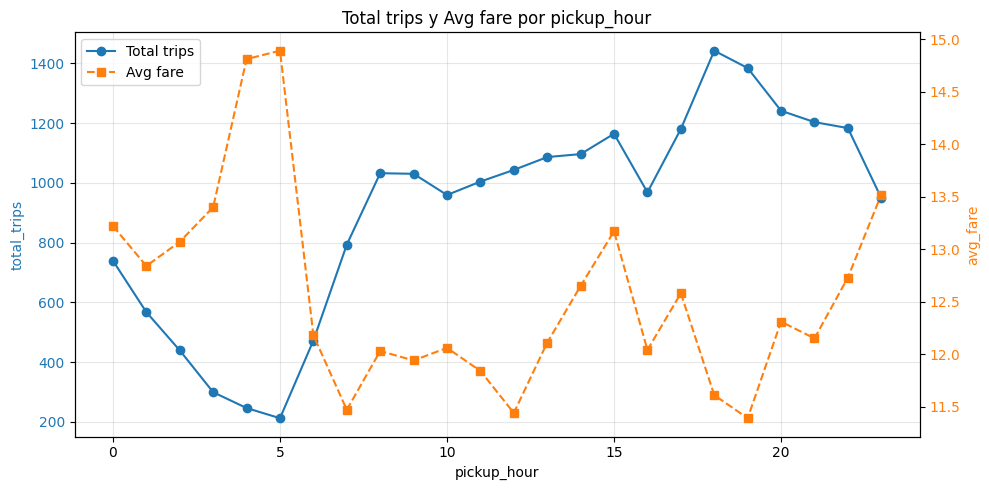

In [0]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = "tab:blue"
ax1.plot(df_hours_to_plot["pickup_hour"], df_hours_to_plot["total_trips"], marker="o", color=color1, label="Total trips")
ax1.set_xlabel("pickup_hour")
ax1.set_ylabel("total_trips", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.plot(df_hours_to_plot["pickup_hour"], df_hours_to_plot["avg_fare"], marker="s", linestyle="--", color=color2, label="Avg fare")
ax2.set_ylabel("avg_fare", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Total trips y Avg fare por pickup_hour")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

In [0]:
df_hours_to_plot

,pickup_hour,total_trips,avg_fare
0,0,739,13.22
1,1,567,12.84
2,2,439,13.07
3,3,299,13.40
4,4,246,14.81
5,5,212,14.89
6,6,472,12.18
7,7,793,11.47
8,8,1032,12.03
9,9,1030,11.94


In [0]:
%sql
SELECT
    time_of_day,
    is_weekend,
    COUNT(*) AS trips,
    ROUND(AVG(fare_amount), 2) AS avg_fare
FROM workspace.taxi_lab.silver_trips
GROUP BY time_of_day, is_weekend
ORDER BY time_of_day, is_weekend

time_of_day,is_weekend,trips,avg_fare
afternoon,0,4474,12.62
afternoon,1,2063,11.78
evening,0,3888,11.87
evening,1,1382,11.76
morning,0,4270,12.06
morning,1,1020,11.28
night,0,2726,13.76
night,1,1908,12.57


In [0]:
df_to_matrix = spark.sql('''
    SELECT
        time_of_day,
        is_weekend,
        COUNT(*) AS trips,
        ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM workspace.taxi_lab.silver_trips
    GROUP BY time_of_day, is_weekend
    ORDER BY time_of_day, is_weekend
''').toPandas()

In [0]:
df_to_matrix

,time_of_day,is_weekend,trips,avg_fare
0,afternoon,0,4474,12.62
1,afternoon,1,2063,11.78
2,evening,0,3888,11.87
3,evening,1,1382,11.76
4,morning,0,4270,12.06
5,morning,1,1020,11.28
6,night,0,2726,13.76
7,night,1,1908,12.57


<Axes: xlabel='is_weekend', ylabel='time_of_day'>

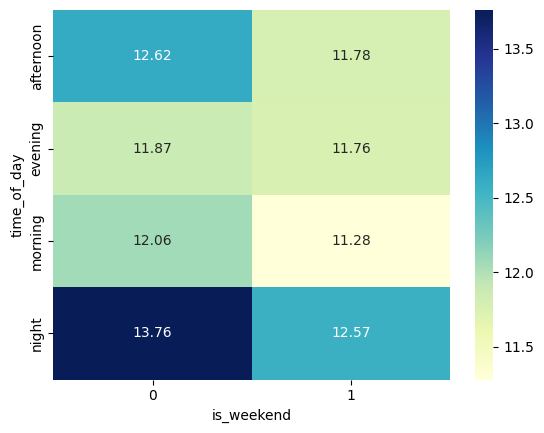

In [0]:
sns.heatmap(
    pd.crosstab(index=df_to_matrix.time_of_day, columns=df_to_matrix.is_weekend,
                values=df_to_matrix.avg_fare, aggfunc='mean'),
    annot=True, cmap="YlGnBu", fmt=".2f"
)

<Axes: xlabel='is_weekend', ylabel='time_of_day'>

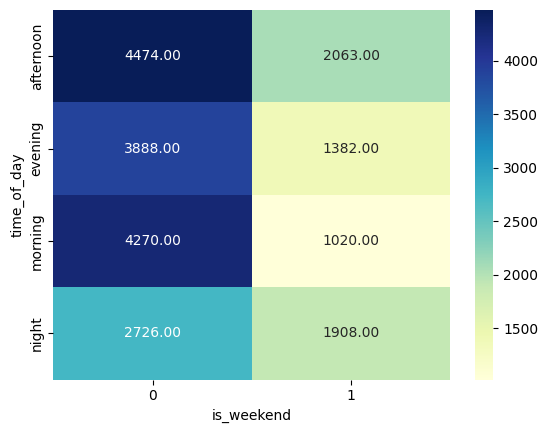

In [0]:
sns.heatmap(
    pd.crosstab(index=df_to_matrix.time_of_day, columns=df_to_matrix.is_weekend,
                values=df_to_matrix.trips, aggfunc='mean'),
    annot=True, cmap="YlGnBu", fmt=".2f"
)

In [0]:
%sql
SELECT
    pickup_zip,
    SUM(total_trips) AS trips_totales,
    ROUND(SUM(total_revenue), 2) AS revenue_total,
    ROUND(AVG(avg_fare), 2) AS tarifa_promedio
FROM workspace.taxi_lab.gold_zone_metrics
GROUP BY pickup_zip
ORDER BY revenue_total DESC
LIMIT 10

pickup_zip,trips_totales,revenue_total,tarifa_promedio
11422,414,18822.5,45.29
11371,479,14650.0,30.5
10001,1218,12983.51,10.66
10003,1173,12894.0,10.82
10011,1124,12225.0,10.8
10018,1001,11491.01,11.45
10021,1014,10313.0,10.22
10023,1005,10106.0,10.18
10012,827,9445.0,11.32
10028,921,9405.5,10.45


In [0]:
display(
    df_silver.select("trip_distance", "trip_duration_min", "fare_amount", "avg_speed_mph")
             .sample(0.1, seed=42)
)

trip_distance,trip_duration_min,fare_amount,avg_speed_mph
0.93,10.866666666666667,8.0,5.134969325153374
2.0,13.65,10.5,8.79120879120879
3.5,23.3,17.5,9.012875536480687
0.6,3.4833333333333334,4.5,10.334928229665072
1.06,10.366666666666667,8.0,6.135048231511254
19.6,40.35,54.5,29.144981412639407
3.14,31.15,19.5,6.048154093097914
2.1,6.533333333333333,8.5,19.28571428571429
2.95,14.066666666666666,12.0,12.582938388625594
8.9,58.15,40.5,9.183147033533965


# Machine Learning

## Prepare ML dataset

In [0]:
df_ml = df_silver.sample(fraction=0.5, seed=42)
print(f"Filas para ML: {df_ml.count():,}")

Filas para ML: 10,783


## Train / test split

In [0]:
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count():,}")
print(f"Test:  {test_df.count():,}")

Train: 8,558
Test:  2,225


## Feature pipeline

In [0]:
indexer = StringIndexer(inputCol="time_of_day", outputCol="time_of_day_idx", handleInvalid="keep")
encoder = OneHotEncoder(inputCol="time_of_day_idx", outputCol="time_of_day_vec")

feature_cols = [
    "trip_distance",
    "trip_duration_min",
    "pickup_hour",
    "pickup_dayofweek",
    "is_weekend",
    "time_of_day_vec"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

In [0]:
evaluator_rmse = RegressionEvaluator(labelCol="fare_amount", predictionCol="prediction", metricName="rmse")
evaluator_r2   = RegressionEvaluator(labelCol="fare_amount", predictionCol="prediction", metricName="r2")

## Linear Regression

In [0]:
lr = LinearRegression(featuresCol="features", labelCol="fare_amount")
pipeline_lr = Pipeline(stages=[indexer, encoder, assembler, lr])

model_lr = pipeline_lr.fit(train_df)
pred_lr = model_lr.transform(test_df)

rmse_lr = evaluator_rmse.evaluate(pred_lr)
r2_lr   = evaluator_r2.evaluate(pred_lr)

mlflow.log_metric("test_rmse", rmse_lr)
mlflow.log_metric("test_r2", r2_lr)

print(f"Linear Regression — RMSE: {rmse_lr:.3f} | R²: {r2_lr:.4f}")

Linear Regression — RMSE: 1.715 | R²: 0.9711


## Random Forest

In [0]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="fare_amount",
    numTrees=20,
    maxDepth=8,
    seed=42
)
pipeline_rf = Pipeline(stages=[indexer, encoder, assembler, rf])

model_rf = pipeline_rf.fit(train_df)
pred_rf = model_rf.transform(test_df)

rmse_rf = evaluator_rmse.evaluate(pred_rf)
r2_rf   = evaluator_r2.evaluate(pred_rf)

mlflow.log_metric("test_rmse", rmse_rf)
mlflow.log_metric("test_r2", r2_rf)

print(f"Random Forest — RMSE: {rmse_rf:.3f} | R²: {r2_rf:.4f}")

Random Forest — RMSE: 2.509 | R²: 0.9382


## Compare models

In [0]:
resultados = pd.DataFrame({
    "modelo": ["Linear Regression", "Random Forest"],
    "RMSE":   [round(rmse_lr, 3), round(rmse_rf, 3)],
    "R²":     [round(r2_lr, 4),   round(r2_rf, 4)]
})
print(resultados.to_string(index=False))

ganador = "Random Forest" if rmse_rf < rmse_lr else "Linear Regression"
print(f"\nMejor modelo (menor RMSE): {ganador}")

           modelo  RMSE     R²
Linear Regression 1.715 0.9711
    Random Forest 2.509 0.9382

Mejor modelo (menor RMSE): Linear Regression


In [0]:
display(
    pred_rf.select("trip_distance", "trip_duration_min", "fare_amount", "prediction")
           .withColumn("error", F.round(F.col("prediction") - F.col("fare_amount"), 2))
           .limit(20)
)

trip_distance,trip_duration_min,fare_amount,prediction,error
1.86,15.316666666666666,11.5,11.250466276492078,-0.25
2.6,21.183333333333334,15.0,14.711173395383236,-0.29
0.7,4.266666666666667,5.0,5.400345393583273,0.4
0.89,6.8,6.5,6.915443684216143,0.42
2.0,6.483333333333333,8.0,8.714337097096479,0.71
1.9,13.766666666666667,10.5,10.985261493953733,0.49
1.1,6.966666666666667,6.5,7.06338192598746,0.56
4.2,19.316666666666666,16.0,16.669132887376872,0.67
6.04,15.216666666666667,19.5,17.64197351958482,-1.86
3.91,16.433333333333334,15.0,15.570194136598172,0.57


## Feature importance

In [0]:
rf_model = model_rf.stages[-1]

feature_names = ["trip_distance", "trip_duration_min", "pickup_hour",
                 "pickup_dayofweek", "is_weekend", "time_of_day_vec"]

importancias = list(zip(feature_names, rf_model.featureImportances.toArray()))
importancias_df = pd.DataFrame(importancias, columns=["feature", "importance"]).sort_values("importance", ascending=False)

display(spark.createDataFrame(importancias_df))

feature,importance
trip_distance,0.5272253365516784
trip_duration_min,0.431161416355319
pickup_hour,0.01741207002589647
pickup_dayofweek,0.013170291480196916
is_weekend,0.001890329823035249
time_of_day_vec,9.79998028695433E-4


# Cleanup

In [0]:
%sql
DROP TABLE IF EXISTS workspace.taxi_lab.bronze_trips;
DROP TABLE IF EXISTS workspace.taxi_lab.silver_trips;
DROP TABLE IF EXISTS workspace.taxi_lab.gold_zone_metrics;